# 1- Problema: Detectar inadimplência de cartão de credito

## 1-1 Explicação da base de dados

### Traduzido para Português

Fonte: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients
Informações sobre o Conjunto de Dados

Esta pesquisa utilizou uma variável binária, inadimplência (Sim = 1, Não = 0), como variável resposta. Este estudo revisou a literatura e utilizou as seguintes 23 variáveis ​​como variáveis ​​explicativas:

LIMIT_BAL: Valor do crédito concedido (em NT$): inclui tanto o crédito individual ao consumidor quanto o crédito familiar (suplementar).

SEX: Sexo (1 = masculino; 2 = feminino).

EDUCATION: Escolaridade (1 = pós-graduação; 2 = ensino superior; 3 = ensino médio; 4 = outros).

MARRIAGE: Estado civil (1 = casado(a); 2 = solteiro(a); 3 = outros).

AGE: Idade (em anos).

PAY_1 a PAY_6: Histórico de pagamentos. Acompanhamos os registros de pagamentos mensais anteriores (de abril a setembro de 2005) da seguinte forma: PAY_1 = situação do pagamento em setembro de 2005; PAY_2 = situação do pagamento em agosto de 2005; ... PAY_6 = situação de pagamento em abril de 2005. A escala de medição da situação de pagamento é: -1 = pago em dia; 1 = atraso de um mês; 2 = atraso de dois meses; ...; 8 = atraso de oito meses; 9 = atraso de nove meses ou mais.

BILL_AMT1-BILL_AMT6: Valor da fatura (dólares taiwaneses). BILL_AMT1 = valor da fatura em setembro de 2005; BILL_AMT2 = valor da fatura em agosto de 2005; ...; BILL_AMT6 = valor da fatura em abril de 2005.

PAY_AMT1-PAY_AMT6: Valor do pagamento anterior (dólares taiwaneses). PAY_AMT1 = valor pago em setembro de 2005; PAY_AMT2 = valor pago em agosto de 2005; ...; PAY_AMT6 = valor pago em abril de 2005.


### Objetivo

Prever a inadimplência de clientes de cartão de crédito no mês subsequente utilizando modelos de machine learning com melhor desempenho.

# 2- Exploração dos Dados

## 2-1 Imports

In [1]:
import os
import pandas as pd

## Importar dados de base publica do google drive

file_id = '1iZFmr0ys8g_3BGc3jlE8UQ8hNFlOmY5s'

url = f'https://drive.google.com/uc?export=download&id={file_id}'


df = pd.read_csv(url)
display(df.head())

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


##2-2 Exploração dos features

### 2-2-1 - Ponto importante - Distribuição do target

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_1                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [3]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


Data set sem nulos e totalmente transformado em números

In [4]:
## Apresentação da distribuição do target: default payment next month:
target_distribution = df['default payment next month'].value_counts()
display(target_distribution)
target_percentage = df['default payment next month'].value_counts(normalize=True) * 100
print('\nPercentage Distribution:')
display(target_percentage)

,count
default payment next month,
0,23364
1,6636



Percentage Distribution:


,proportion
default payment next month,
0,77.88
1,22.12


0= Adimplente e 1 = Inadimplente
Sendo a base desbalanceada conforme distribuição acima

### 2-2-2 - Conferindo features categóricas conforme documentação

In [5]:
# Tirando o id do df
df = df.drop('ID', axis=1)

#### Feature: SEX

In [6]:
## Conferindo se as variáveis categoricas estão condizentes com documentação
## Conferiando se a feature SEX só possuí 1 e 2 e conferindo distribuição
print(df['SEX'].unique())
SEX_distribution = df['SEX'].value_counts()
display(SEX_distribution)
SEX_percentage = df['SEX'].value_counts(normalize=True) * 100
print('\nPercentage Distribution:')
display(SEX_percentage)
#SEX: Sexo (1 = masculino; 2 = feminino).

[2 1]


,count
SEX,
2,18112
1,11888



Percentage Distribution:


,proportion
SEX,
2,60.373333
1,39.626667


#### Feature: EDUCATION

In [7]:
#Conferindo se EDUCATION está condizente com:
#EDUCATION: Escolaridade (1 = pós-graduação; 2 = ensino superior; 3 = ensino médio; 4 = outros)
#cria o unique do education e imprime de forma crescente
education_unique = pd.DataFrame(sorted(df['EDUCATION'].unique()), columns=['EDUCATION'])
display(education_unique)

,EDUCATION
0,0
1,1
2,2
3,3
4,4
5,5
6,6


In [8]:
# Transformar no df os valores 0, 5 E 6 PARA 4 da coluna EDUCATION, uma vez que esses valores não estão na documentação, se transformarão em "outros"
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
#

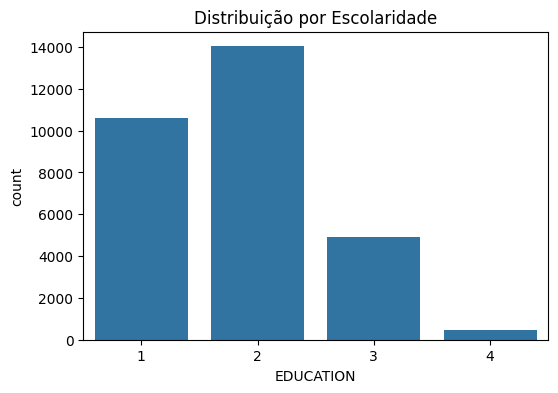

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='EDUCATION', data=df)
plt.title('Distribuição por Escolaridade')
plt.show()

Escolaridade: 1 = pós-graduação; 2 = ensino superior; 3 = ensino médio e  4 =
outros

#### Feature: MARRIAGE

In [10]:
#Confere valores da feature MARRIAGE
#MARRIAGE: Estado civil (1 = casado(a); 2 = solteiro(a); 3 = outros).
print(df['MARRIAGE'].unique())

[1 2 3 0]


In [11]:
# Transforma valor 0 para 3 (outros) da feature MARRIAGE
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})

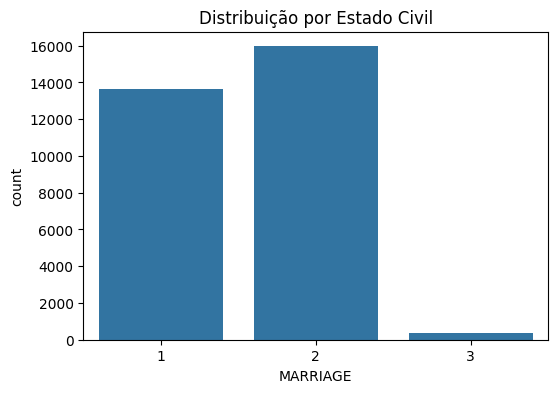

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='MARRIAGE', data=df)
plt.title('Distribuição por Estado Civil')
plt.show()

Estado civil: 1 = casado; 2 = solteiro e 3 = outros

#### Feature: AGE

In [13]:
#print AGE unique ordenada
AGE_unique = pd.DataFrame(sorted(df['AGE'].unique()), columns=['AGE'])
display(AGE_unique)

,AGE
0,21
1,22
2,23
3,24
4,25
5,26
6,27
7,28
8,29
9,30


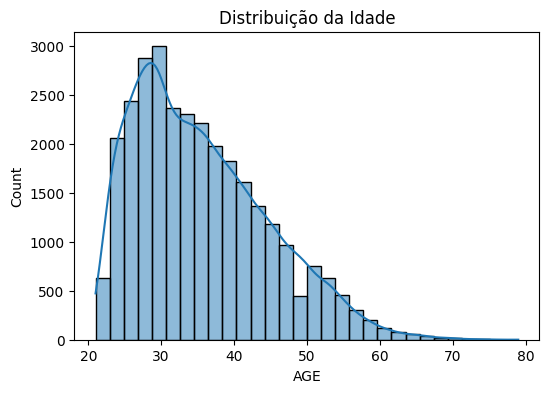

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(df['AGE'], bins=30, kde=True)
plt.title('Distribuição da Idade')
plt.show()

#### Feature: Limite de Crédito

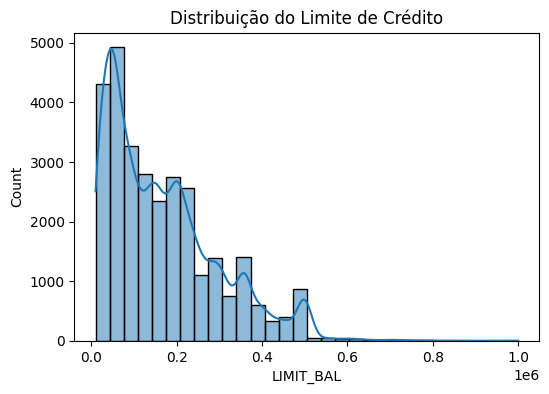

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df['LIMIT_BAL'], bins=30, kde=True)
plt.title('Distribuição do Limite de Crédito')
plt.show()

### 2-2-3 Relações de Features com Targe

In [16]:
# Correlação com a variável target ('default payment next month')
correlation_with_target = df.corr()['default payment next month'].sort_values(ascending=False)
display(correlation_with_target)

,default payment next month
default payment next month,1.000000
PAY_1,0.324794
PAY_2,0.263551
PAY_3,0.235253
PAY_4,0.216614
PAY_5,0.204149
PAY_6,0.186866
EDUCATION,0.033842
AGE,0.013890
BILL_AMT6,-0.005372


A correlação evidenciou que as variáveis relacionadas ao histórico de pagamento (PAY_1 a PAY_6) apresentam maior relação com a inadimplência, indicando que atrasos anteriores são fortes preditores de risco

In [17]:
df.groupby('default payment next month')['LIMIT_BAL'].mean()

,LIMIT_BAL
default payment next month,
0,178099.726074
1,130109.656420


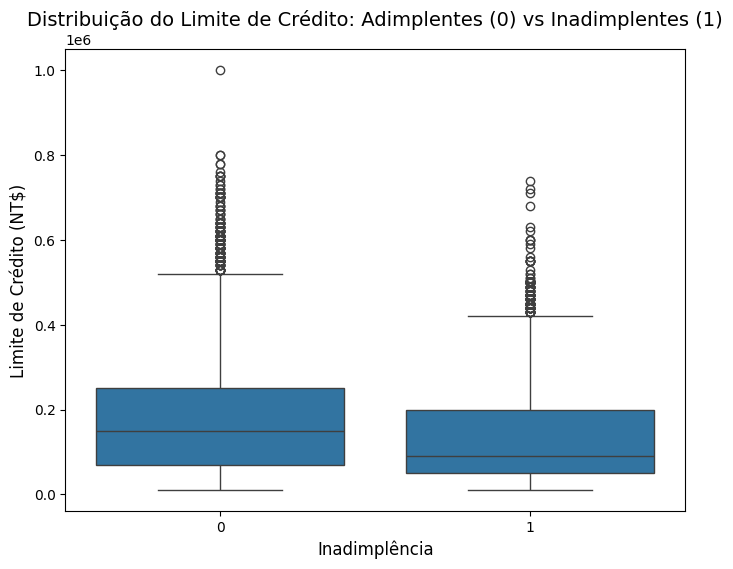

In [18]:
# Distribuição de Limite de Crédito por Target
plt.figure(figsize=(8, 6))
sns.boxplot(x='default payment next month', y='LIMIT_BAL', data=df)
plt.title('Distribuição do Limite de Crédito: Adimplentes (0) vs Inadimplentes (1)', fontsize=14)
plt.xlabel('Inadimplência', fontsize=12)
plt.ylabel('Limite de Crédito (NT$)', fontsize=12)
plt.show()

Clientes inadimplentes tem a média de limite mais baixa que clientes adimplentes

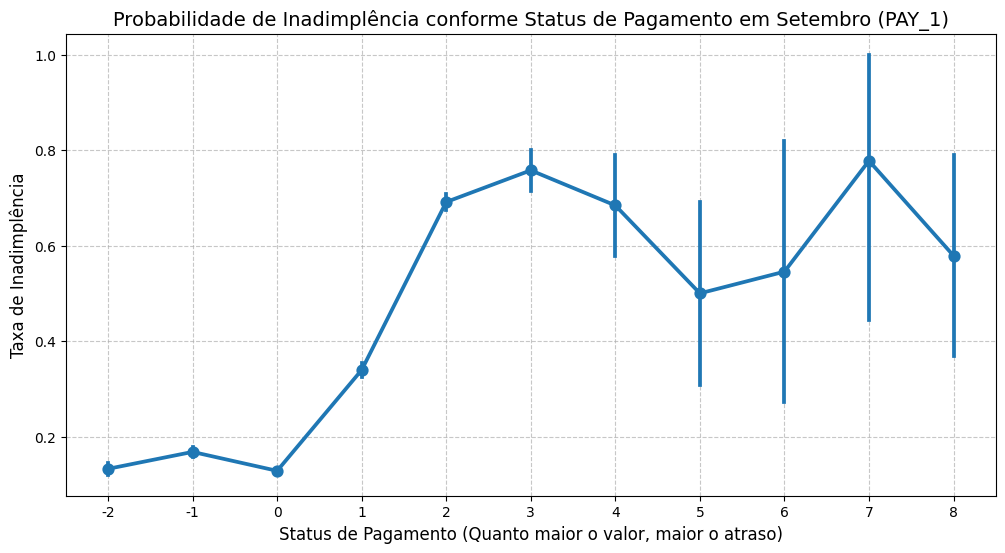

In [19]:
# Relação entre Status de Pagamento (Setembro/Pay_1 com maior correlação) e Inadimplência
plt.figure(figsize=(12, 6))
sns.pointplot(x='PAY_1', y='default payment next month', data=df)
plt.title('Probabilidade de Inadimplência conforme Status de Pagamento em Setembro (PAY_1)', fontsize=14)
plt.xlabel('Status de Pagamento (Quanto maior o valor, maior o atraso)', fontsize=12)
plt.ylabel('Taxa de Inadimplência', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Observa-se crescimento exponencial no risco de crédito quando o cliente atinge dois meses de atraso (valor 2), onde a taxa de inadimplência salta de aproximadamente 10% (clientes em dia) para cerca de 70% - (aqui eu pedi uma ajuda da IA pra plotar uma boa visualização, mais acho que ta meio ruim explicar, avaliar uma forma melhor de apresentar esses dados)

##3 - Pré-Processamento dos dados

In [20]:
# Separação entre X e Y (features e target)
X = df.drop('default payment next month', axis=1)
y = df['default payment next month']

Y= Target e X= Outras colunas

### 3-1 Separação dos dados em treino, validação e teste

In [21]:
from sklearn.model_selection import train_test_split

SEED = 42

# Separação treino + teste (80/20)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

# Separação treino + validação (80/20 do restante)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=SEED,
    stratify=y_temp
)

print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

Treino: (18000, 23)
Validação: (6000, 23)
Teste: (6000, 23)


Separação treino (60%) para aprendiazem, validação (20%) para ajuste e seleção de modelo e teste (20%) para avaliação final. Evitando overfiting (quando modelo decora a base mas não aprende, tendo desempenho ruim quando aplicado novos dados)

### 3-2 One-Hot Encoding

Transformação das variáveis categóricas, o alinhamento ajusta as colunas na memsa ordem para que não tenha problemas na hora de rodar os modelos

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
num_cols = [col for col in X_train.columns if col not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ],
    remainder='drop'
)

# Fit no treino
preprocess.fit(X_train)

# Transformação
X_train_proc = preprocess.transform(X_train)
X_val_proc   = preprocess.transform(X_val)
X_test_proc  = preprocess.transform(X_test)

print(X_train_proc.shape)
print(X_val_proc.shape)
print(X_test_proc.shape)

(18000, 29)
(6000, 29)
(6000, 29)


### 3-3 Ajuste de desbalaceamento

---



In [23]:
#from imblearn.over_sampling import SMOTE

#smote = SMOTE(random_state=42)

#X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)

#print("Antes:", y_train.value_counts())
#print("Depois:", y_train_res.value_counts())

Criação de novas amostras sintéticas da classe minoritária. Aplicada apenas a base de treino, evitando vazamento/memorização de informação na validação e teste.

O Smote (atua no dado) cria novos dados sintéticos aumentando a base minoritária (inadimplente) reproduzindo exemplos reais com pontos parecidos, já o Class Weight (atua no modelo) não aumenta a base, ele atribui um peso maior a classe minoritária. Usar os dois pode gerar supervalorização da classe minoritária, aqui podemos comparar os dois ou selecionar um. Neste caso, usei o class weight que é mais simples, não “cria” dados e interage bem com os modelos selecionados.

### 4 Aplicação dos Modelos

In [24]:
#Separação dos dados
X_train_proc, X_val_proc, X_test_proc
y_train, y_val, y_test

(10574    0
 11330    0
 7127     0
 25150    0
 6000     0
         ..
 22847    0
 17496    1
 2145     0
 15305    0
 25509    0
 Name: default payment next month, Length: 18000, dtype: int64,
 18316    1
 1482     0
 10396    1
 9360     0
 18144    0
         ..
 13601    0
 23556    0
 1797     0
 6446     0
 5323     0
 Name: default payment next month, Length: 6000, dtype: int64,
 6907     0
 24575    0
 26766    0
 2156     1
 3179     0
         ..
 8836     0
 1259     0
 27309    0
 29583    0
 24399    0
 Name: default payment next month, Length: 6000, dtype: int64)

### 4-1 Regressão Logistica

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_proc, y_train)

y_val_pred = log_model.predict(X_val_proc)
y_val_prob = log_model.predict_proba(X_val_proc)[:,1]

print("Regressão Logística")
print(classification_report(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))

Regressão Logística
              precision    recall  f1-score   support

           0       0.88      0.70      0.78      4673
           1       0.38      0.66      0.48      1327

    accuracy                           0.69      6000
   macro avg       0.63      0.68      0.63      6000
weighted avg       0.77      0.69      0.71      6000

ROC-AUC: 0.7270209452528442


### 4-2 SVM

In [26]:
from sklearn.svm import SVC

svm_model = SVC(
    class_weight='balanced',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_proc, y_train)

y_val_pred = svm_model.predict(X_val_proc)
y_val_prob = svm_model.predict_proba(X_val_proc)[:,1]

print("SVM")
print(classification_report(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))

SVM
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      4673
           1       0.50      0.57      0.53      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.70      0.69      6000
weighted avg       0.79      0.78      0.78      6000

ROC-AUC: 0.7656328237493168


### 4-3 Random Forest

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train_proc, y_train)

y_val_pred = rf_model.predict(X_val_proc)
y_val_prob = rf_model.predict_proba(X_val_proc)[:,1]

print("Random Forest")
print(classification_report(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4673
           1       0.67      0.33      0.44      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.64      0.67      6000
weighted avg       0.80      0.82      0.79      6000

ROC-AUC: 0.7710902681165882


### 4-4 GXBoost

In [28]:
from xgboost import XGBClassifier
import numpy as np

neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_proc, y_train)

y_val_pred = xgb_model.predict(X_val_proc)
y_val_prob = xgb_model.predict_proba(X_val_proc)[:,1]

print("XGBoost")
print(classification_report(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))

XGBoost
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      4673
           1       0.47      0.57      0.51      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.69      0.68      6000
weighted avg       0.78      0.76      0.77      6000

ROC-AUC: 0.752070972901294


### 4-5 LSTM

### 4-6 Volting Classifier

In [29]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ('lr', log_model),
        ('rf', rf_model),
        ('xgb', xgb_model)
    ],
    voting='soft'
)

voting_model.fit(X_train_proc, y_train)

y_val_pred = voting_model.predict(X_val_proc)
y_val_prob = voting_model.predict_proba(X_val_proc)[:,1]

print("Voting Classifier")
print(classification_report(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))

Voting Classifier
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      4673
           1       0.58      0.49      0.53      1327

    accuracy                           0.81      6000
   macro avg       0.72      0.69      0.70      6000
weighted avg       0.80      0.81      0.80      6000

ROC-AUC: 0.7700646388341627


### 5 Avaliação final de desempenho

### 5-1 Avaliação dos modelos

In [31]:
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score, accuracy_score

def avaliar_modelo(nome_modelo, model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    print(f"\n--- {nome_modelo} ---")
    print(classification_report(y, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y, y_prob):.3f}")

def metricas(model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    return {
        'accuracy': accuracy_score(y, y_pred),
        'precision': precision_score(y, y_pred),
        'recall': recall_score(y, y_pred),
        'f1': f1_score(y, y_pred),
        'roc_auc': roc_auc_score(y, y_prob)
    }

avaliar_modelo("Logistic Regression", log_model, X_test_proc, y_test)
avaliar_modelo("SVM", svm_model, X_test_proc, y_test)
avaliar_modelo("Random Forest", rf_model, X_test_proc, y_test)
avaliar_modelo("XGBoost", xgb_model, X_test_proc, y_test)
avaliar_modelo("Voting", voting_model, X_test_proc, y_test)


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.87      0.69      0.77      4673
           1       0.37      0.64      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000

ROC-AUC: 0.712

--- SVM ---
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      4673
           1       0.49      0.56      0.52      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.70      0.69      6000
weighted avg       0.79      0.78      0.78      6000

ROC-AUC: 0.751

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4673
           1       0.65      0.34      0.44      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.64

In [32]:
import pandas as pd

resultados = pd.DataFrame({
    "Logistic": metricas(log_model, X_test_proc, y_test),
    "SVM": metricas(svm_model, X_test_proc, y_test),
    "RandomForest": metricas(rf_model, X_test_proc, y_test),
    "XGBoost": metricas(xgb_model, X_test_proc, y_test),
    "Voting": metricas(voting_model, X_test_proc, y_test)
}).T

print(resultados)

              accuracy  precision    recall        f1   roc_auc
Logistic      0.675667   0.365727  0.635268  0.464207  0.711627
SVM           0.775000   0.492349  0.557649  0.522968  0.751290
RandomForest  0.812500   0.646802  0.335343  0.441687  0.756315
XGBoost       0.755000   0.454545  0.538809  0.493103  0.746276
Voting        0.799333   0.554473  0.471741  0.509772  0.757401


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc_multiplos(modelos, X, y):
    plt.figure()

    for nome, model in modelos.items():
        y_prob = model.predict_proba(X)[:,1]
        fpr, tpr, _ = roc_curve(y, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f'{nome} (AUC={roc_auc:.3f})')

    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Curva ROC - Comparação de Modelos')
    plt.legend()
    plt.show()

modelos = {
    "Logistic": log_model,
    "SVM": svm_model,
    "RF": rf_model,
    "XGB": xgb_model,
    "Voting": voting_model
}

plot_roc_multiplos(modelos, X_test_proc, y_test)

Modelos possuem boa capacidade de separação entre adimplentes e inadimplentes. O Voiting classifier no geral tem melhor desempenho, com o AUC de 0,757, em seguida vem os modelos Radom Forest e SVM.

In [ ]:
from sklearn.metrics import precision_recall_curve

def plot_pr_multiplos(modelos, X, y):
    plt.figure()

    for nome, model in modelos.items():
        y_prob = model.predict_proba(X)[:,1]
        precision, recall, _ = precision_recall_curve(y, y_prob)

        plt.plot(recall, precision, label=nome)

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curva Precision-Recall')
    plt.legend()
    plt.show()

plot_pr_multiplos(modelos, X_test_proc, y_test)

Esse indicador evidencia o desempenho de modelos com classes minoritarias. O modelo SVM tem o melhor equilibrio entre precisão e recall ao longo da curva.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrices(modelos, X, y):
    n = len(modelos)
    cols = 3
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(15, 5 * rows))

    for i, (nome, model) in enumerate(modelos.items()):
        y_pred = model.predict(X)
        cm = confusion_matrix(y, y_pred)

        ax = plt.subplot(rows, cols, i + 1)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(ax=ax, cmap='Blues', colorbar=False)  # 👈 AQUI

        ax.set_title(nome)

    plt.tight_layout()
    plt.show()

modelos = {
    "Logistic": log_model,
    "SVM": svm_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "Voting": voting_model
}

plot_confusion_matrices(modelos, X_test_proc, y_test)

Regressão Logistica: maior capacidade de indentificar inadimplentes (alto recall), mas com um volume alto de falsos positivos.

SVM: apresenta um equilibrio entre precisão e recall, reduzindo o falso positivo, com boa  capacidade de detecção.

Random forest: foi bem conservador, tem alta precisão e com baixos falsos positivos, mas com baixa capacidade de identificar inadimplentes.

XGBoost: tem desempenho razoavel, mas sem se destacar em nenhuma métrica.

Voting Classifier: melhor equilibrio entre inadimples e falsos positivos.

Em resumo, não existe melhor modelo em todos os aspectos mas o Voting classifier tem o melhor equilibrio.